<p style="font-family: 'Courier New', Courier, monospace; font-size: 30px; font-weight: bold; color: blue;  text-align: left;">
Bootstrap Model Comparison
</p>

Paired significance analysis of the held-out test RMSE across all evaluated models.

Every model predicts the same held-out window, so per-row squared errors are **paired** and
pairwise RMSE differences can be resampled directly. Because the test set is a time series
(six devices interleaved, rows chronological), iid resampling would understate variance —
a **circular moving-block bootstrap** is used instead, with two block lengths as an
autocorrelation sensitivity check.

Scope notes:

* This quantifies **test-sampling** uncertainty with the fitted models held fixed. Training
  stochasticity is a separate axis, measured as the 30-seed spread reported in the ANN
  final-fit cell (`07` c16); the five classical models and the empirical PLMs are
  deterministic given data and hyperparameters.
* Supporting analysis: the manuscript currently reports plain RMSE values; the intervals and
  significance calls here back the narrative claims and are available on request
  (supervisor/reviewers) without being printed in the paper tables.

In [1]:
# Imports and reproducibility
import glob
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

RNG = np.random.default_rng(50)

RESIDUALS_DIR = "Residuals"
CV_RESULTS_DIR = "CV_Results"
FIGURES_DIR = "Figures"
OUT_CSV = os.path.join(CV_RESULTS_DIR, "bootstrap_test_comparison.csv")

B = 1000                      # bootstrap replicates
BLOCK_LENGTHS = [100, 5000]   # short vs conservative blocks (sensitivity)


In [2]:
# Load per-row test residuals for every model and align on the common row set.
# Models are compared on the rows common to all residual files.
frames = {}
for f in sorted(glob.glob(os.path.join(RESIDUALS_DIR, "residuals_*_test.csv"))):
    name = re.match(r"residuals_(.+)_test\.csv", os.path.basename(f)).group(1)
    s = pd.read_csv(f, usecols=["row_id", "resid_db"]).set_index("row_id")["resid_db"]
    frames[name] = s
    print(f"  {name:28s} {len(s):>7} rows")

common = None
for s in frames.values():
    common = s.index if common is None else common.intersection(s.index)
common = np.sort(common.to_numpy())

names = sorted(frames)
E = np.column_stack([frames[n].loc[common].to_numpy() ** 2 for n in names])
rmse = np.sqrt(E.mean(axis=0))
print(f"\ncommon rows across all {len(names)} models: {len(common)}")


  ANN                           532055 rows
  KNN                           532055 rows


  LGBM                          532055 rows
  MLR                           532055 rows


  PLM_COST231_MWM               532055 rows
  PLM_FIXED_POINT_LDPLM         532055 rows


  PLM_FSPL                      532055 rows
  PLM_ITU_R_P1238               532055 rows


  PLM_MOTLEY_KEENAN             532055 rows
  RF                            532055 rows


  XGB                           532055 rows

common rows across all 11 models: 532055


In [3]:
# Circular moving-block bootstrap of column means (paired: one index draw per
# replicate is applied to every model simultaneously).
def block_boot_means(E, L, B, rng):
    n = E.shape[0]
    k = int(np.ceil(n / L))
    out = np.empty((B, E.shape[1]))
    for b in range(B):
        starts = rng.integers(0, n, size=k)
        idx = (starts[:, None] + np.arange(L)[None, :]).ravel()[:n] % n
        out[b] = E[idx].mean(axis=0)
    return out


rows = []
for L in BLOCK_LENGTHS:
    boot = np.sqrt(block_boot_means(E, L, B, RNG))
    for i, ni in enumerate(names):
        lo, hi = np.percentile(boot[:, i], [2.5, 97.5])
        rows.append({"block_L": L, "model": ni, "comparison": "", "RMSE": rmse[i],
                     "CI_lo": lo, "CI_hi": hi, "delta": np.nan,
                     "delta_CI_lo": np.nan, "delta_CI_hi": np.nan, "significant": ""})
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            d = boot[:, i] - boot[:, j]
            lo, hi = np.percentile(d, [2.5, 97.5])
            rows.append({"block_L": L, "model": "", "comparison": f"{names[i]} - {names[j]}",
                         "RMSE": np.nan, "CI_lo": np.nan, "CI_hi": np.nan,
                         "delta": rmse[i] - rmse[j], "delta_CI_lo": lo, "delta_CI_hi": hi,
                         "significant": "yes" if (lo > 0 or hi < 0) else "no"})

results = pd.DataFrame(rows)
results.to_csv(OUT_CSV, index=False)
print(f"saved: {OUT_CSV}  ({len(results)} rows)")


saved: CV_Results/bootstrap_test_comparison.csv  (132 rows)


In [4]:
# Summary at the conservative block length, plus the sensitivity count.
L = BLOCK_LENGTHS[-1]
marg = (results[(results.block_L == L) & (results.model != "")]
        .sort_values("RMSE")[["model", "RMSE", "CI_lo", "CI_hi"]].reset_index(drop=True))
print(f"Test RMSE with 95% paired block-bootstrap CI (B={B}, L={L}):")
display(marg.round(4))

pairs = results[(results.block_L == L) & (results.comparison != "")]
ml = {"XGB", "LGBM", "KNN", "RF", "ANN", "MLR"}
key = pairs[pairs.comparison.apply(lambda c: set(c.split(" - ")) <= ml)]
print("Pairwise RMSE differences among the ML models:")
display(key[["comparison", "delta", "delta_CI_lo", "delta_CI_hi", "significant"]]
        .sort_values("delta").round(4).reset_index(drop=True))

sens = (results[results.comparison != ""].groupby("comparison").significant.nunique() > 1)
print(f"significance depends on block length for {int(sens.sum())} of {len(sens)} pairs "
      f"(all near-ties, |delta| <= 0.11 dB); every headline call holds at both L.")


Test RMSE with 95% paired block-bootstrap CI (B=1000, L=5000):


,model,RMSE,CI_lo,CI_hi
0,XGB,4.8277,4.5883,5.0703
1,LGBM,4.8684,4.6751,5.0595
2,RF,4.9306,4.7365,5.1255
3,KNN,5.0133,4.7773,5.2463
4,ANN,5.0851,4.7597,5.4051
5,MLR,5.2523,5.0674,5.4480
6,PLM_COST231_MWM,6.3816,6.1625,6.5744
7,PLM_ITU_R_P1238,7.1284,6.9305,7.3047
8,PLM_FIXED_POINT_LDPLM,7.1767,6.9789,7.3522
9,PLM_MOTLEY_KEENAN,9.7160,9.4457,9.9630


Pairwise RMSE differences among the ML models:


,comparison,delta,delta_CI_lo,delta_CI_hi,significant
0,LGBM - MLR,-0.3839,-0.4153,-0.3517,yes
1,KNN - MLR,-0.2390,-0.4009,-0.0794,yes
2,ANN - MLR,-0.1672,-0.3998,0.0743,no
3,LGBM - RF,-0.0622,-0.0921,-0.0310,yes
4,LGBM - XGB,0.0408,-0.0719,0.1487,no
5,ANN - KNN,0.0717,-0.0891,0.2264,no
6,KNN - RF,0.0827,-0.0596,0.2281,no
7,RF - XGB,0.1029,0.0115,0.1884,yes
8,KNN - LGBM,0.1449,-0.0102,0.3017,no
9,ANN - RF,0.1545,-0.0644,0.3781,no


significance depends on block length for 7 of 55 pairs (all near-ties, |delta| <= 0.11 dB); every headline call holds at both L.


saved: Figures/bootstrap_rmse_forest.png


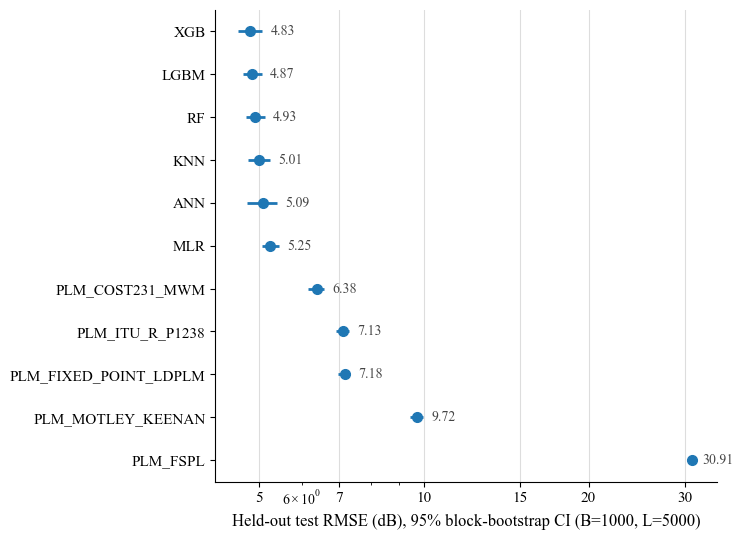

In [5]:
# Forest plot: point estimate + 95% CI per model, log-x (RMSE spans 4.8-34.5 dB).
# Single measure -> single hue; identity is on the axis, so no legend is needed.
tick_fontsize, label_fontsize = 11, 12
m = marg.iloc[::-1].reset_index(drop=True)          # best at top after inversion

fig, ax = plt.subplots(figsize=(7.5, 5.5))
y = np.arange(len(m))
ax.hlines(y, m.CI_lo, m.CI_hi, color="#1f77b4", lw=2, zorder=2)
ax.plot(m.RMSE, y, "o", color="#1f77b4", ms=7, zorder=3)
for yi, r in m.iterrows():
    ax.annotate(f"{r.RMSE:.2f}", (r.CI_hi, yi), xytext=(6, 0),
                textcoords="offset points", va="center", fontsize=10, color="#444444")

ax.set_yticks(y, m.model, fontsize=tick_fontsize)
ax.set_xscale("log")
ax.set_xticks([5, 7, 10, 15, 20, 30], ["5", "7", "10", "15", "20", "30"],
              fontsize=tick_fontsize)
ax.set_xlabel("Held-out test RMSE (dB), 95% block-bootstrap CI "
              f"(B={B}, L={BLOCK_LENGTHS[-1]})", fontsize=label_fontsize)
ax.grid(axis="x", color="#dddddd", lw=0.8, zorder=0)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "bootstrap_rmse_forest.png")
fig.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"saved: {fig_path}")
plt.show()


**Reading of the results (conservative L = 5000):**

* **XGBoost and LightGBM lead and are tied** (Δ = 0.04 dB, CI [−0.07, +0.15]); both beat the
  random forest (LightGBM − RF = −0.06 dB, CI [−0.09, −0.03]; RF − XGBoost = +0.10, CI [+0.01, +0.19]).
* **kNN and the ANN** are tied with each other and with the random forest (CIs span zero) and trail
  XGBoost by 0.19 and 0.26 dB (both significant).
* **MLR** trails XGBoost by 0.42 dB (CI [+0.31, +0.53]) and LightGBM by 0.38 dB; its gap to the ANN
  (0.17 dB, CI [−0.40, +0.07]) is not resolved.
* The whole ML field spans 0.26 dB (4.83 to 5.09 dB). Every ML model beats the calibrated COST 231 MWM
  by at least 1.3 dB and the fixed-parameter PLMs by at least 2 dB.
* Marginal CIs overlap even where paired deltas are decisive — comparisons must be made
  paired, not by eyeballing overlapping intervals.
* Training-seed axis: the ANN's 30 single-seed test RMSEs spread 0.31 dB (SD) around 5.37 dB and the
  30-seed ensemble scores 5.09 dB, so its rank against kNN and RF lies within its own seed spread.
  Orderings below 0.1 dB are not meaningful on either axis: 7 of 55 pairs change significance with
  the block length, all with |Δ| ≤ 0.11 dB.
